# Attention (self-attention)

To understand self-attention, think of it as a mechanism that allows a model to "re-weight" its understanding of a word based on the words surrounding it.

In a sentence like "The animal didn't cross the street because it was too tired," self-attention is what helps the model realize that "it" refers to the "animal" and not the "street."

## The Mathematical Formula

The standard "Scaled Dot-Product Attention" is defined as:

$$\text{Attention}(Q, K, V) = \text{softmax} \left( \frac{QK^T}{\sqrt{d_k}} \right) V$$


* `Q`,`K`,`V`: The Query, Key, and Value matrices.

* `QK^T`: Computes the raw similarity scores between every query and every key. The dot product of the queries and keys, which determines the alignment (or "attention") between different parts of the input.

* `sqrt(dk)`​​: A scaling factor (where dk​ is the dimension of the keys) to prevent gradients from exploding/vanishing during training. This prevents the dot products from growing too large in magnitude, which can lead to vanishing gradients during the softmax step.

* `softmax`: Turns scores into probabilities (weights that sum to 1). Normalizes the scores so they sum to 1.

* `V`: Multiplies the weights by the values to get the final "contextualized" representation.

## The Intuition

To understand why self-attention changed the world of AI, you have to look at what came before it. Older models (like RNNs) processed text like a human reading a ticker tape—one word at a time, left to right. If a sentence was 50 words long, the model often "forgot" the beginning by the time it reached the end.

Self-attention changed this by allowing every word to "look" at every other word in the sentence simultaneously.

### The "Library Card" System

Imagine you are in a library. To find information, you use three things:

1. `Query (Q)`: A sticky note in your hand saying, "I'm looking for a feline predator."

2. `Key (K)`: The labels on the spines of the books on the shelf (e.g., "Biology," "Cooking," "Lions").

3. `Value (V)`: The actual information inside the book once you open it.

**Why it works:**
* In a sentence, every word is simultaneously a Query, a Key, and a Value. 
* The word "it" (Query) looks at all other words (Keys). 
* It finds a high match with "Lion" and a low match with "Street." 
* It then takes the "content" (Value) of the word "Lion" and absorbs it into its own meaning.

### The Math: Step-by-Step
Let’s say we have an input matrix $X$, where each row is a word embedding.

#### A. Linear Projections
We multiply $X$ by three learned weight matrices ($W_Q$, $W_K$, $W_V$) to get our specialized vectors:
$$Q = XW_Q, \quad K = XW_K, \quad V = XW_V$$

#### B. The "Similarity" Score (Energy Calculation)
We compute how much each word should care about every other word by taking the dot product of $Q$ and $K$.
$$\text{Score} = QK^T$$

#### C. Scaling and Normalizing
We divide by $\sqrt{d_k}$ (the square root of the dimension) to keep the numbers from getting too large, then apply Softmax.
$$\text{Weights} = \text{softmax} \left( \frac{QK^T}{\sqrt{d_k}} \right)$$

#### D. The Weighted Sum
We multiply those weights by the Values ($V$).
$$\text{Output} = \text{Weights} \cdot V$$



### Why is it so powerful?
* **Parallelization:** Unlike RNNs, Transformers process the entire sequence at once.
* **Dynamic Context:** The word "bank" changes meaning if the surrounding keys are "river" versus "money."
* **Global Reach:** A word at the end of a book can attend to a word at the beginning in one step.


### Multi-Head Attention (MHA): The "Council of Experts"

If you only have one attention mechanism, the model has to average everything together. But a word can have many different types of relationships simultaneously (grammatical, semantic, logical).


Multi-Head Attention splits the Query, Key, and Value vectors into h smaller chunks (heads).

* `Head 1` might focus on: "Who did what?" (Subject-Verb relationship).

* `Head 2` might focus on: "Where did it happen?" (Prepositional context).

* `Head 3` might focus on: "Does this rhyme?" (Linguistic patterns).


By running these in parallel and then concatenating the results at the end, the model gets a multidimensional understanding of the text that a single "eye" would miss.

$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \dots, \text{head}_h)W^O$$
$$\text{where head}_i = \text{Attention}(QW_i^Q, KW_i^K, VW_i^V)$$


## PyTorch Implementation (Self-Attention)


While we call it "attention scores" or "raw weights" in common conversation, calling it energy (or an energy-based model approach) comes from the idea that we are measuring the "affinity" between two vectors.


You'll see this naming convention in many research papers (like the original Bahdanau Attention paper) because:

* It’s a raw score: It hasn't been normalized yet.

* It’s a measure of "effort": It represents how much "focus" or "energy" the Query is putting into a specific Key.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class SelfAttention(nn.Module):
    def __init__(self, embed_size):
        super(SelfAttention, self).__init__()
        self.embed_size = embed_size

        # Linear layers to project input into Q, K, and V
        self.values = nn.Linear(embed_size, embed_size, bias=False)
        self.keys = nn.Linear(embed_size, embed_size, bias=False)
        self.queries = nn.Linear(embed_size, embed_size, bias=False)

    def forward(self, x):
        # x shape: (batch_size, sequence_length, embed_size)
        N, seq_len, _ = x.shape

        # 1. Project inputs into Q, K, V
        queries = self.queries(x)
        keys = self.keys(x)
        values = self.values(x)

        # 2. Scaled Dot-Product: (Q * K^T) / sqrt(d_k)
        # We use matmul; 'queries' is (N, seq_len, d_k)
        # 'keys' is transposed to (N, d_k, seq_len)
        d_k = self.embed_size
        energy = torch.matmul(queries, keys.transpose(-2, -1)) / (d_k**0.5)

        # 3. Apply Softmax to get attention weights
        attention_weights = F.softmax(energy, dim=-1)

        # 4. Multiply weights by Values
        out = torch.matmul(attention_weights, values)

        return out

In [2]:
# Example usage:
# batch=1, 5 words, 128 features each
input_data = torch.randn(1, 5, 128)
attention = SelfAttention(embed_size=128)
output = attention(input_data)
print(output.shape)  # torch.Size([1, 5, 128])

torch.Size([1, 5, 128])


## Pytorch Implementation (Multi-headed Attention)

What you would typically see in traditional Encoder-Decoder Architecture

**The Architecture: "Split, Compute, Merge"**

To implement this efficiently in PyTorch, we use a few tricks:

1. Linear Projections: One big matrix multiplication to get Q,K,V for all heads at once.

2. Reshaping/Transposing: Moving the "heads" dimension so we can do batch matrix multiplication.

3. Scaled Dot-Product: The core QKT math.

4. Concatenation: Gluing the heads back together.

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class MultiHeadAttention(nn.Module):
    def __init__(self, embed_size, heads):
        super(MultiHeadAttention, self).__init__()
        self.embed_size = embed_size
        self.heads = heads
        self.head_dim = embed_size // heads

        assert self.head_dim * heads == embed_size, "Embedding size needs to be divisible by heads"

        # Linear layers for Q, K, and V
        self.values = nn.Linear(self.embed_size, self.embed_size, bias=False)
        self.keys = nn.Linear(self.embed_size, self.embed_size, bias=False)
        self.queries = nn.Linear(self.embed_size, self.embed_size, bias=False)

        # Final output projection
        self.fc_out = nn.Linear(self.embed_size, self.embed_size)

    def forward(self, values, keys, query):
        # Get batch size and sequence lengths
        N = query.shape[0]
        value_len, key_len, query_len = values.shape[1], keys.shape[1], query.shape[1]

        # 1. Project into Q, K, V
        # Shape: (N, seq_len, embed_size)
        v = self.values(values)
        k = self.keys(keys)
        q = self.queries(query)

        # 2. Split into multiple heads
        # From: (N, seq_len, embed_size)
        # To:   (N, seq_len, heads, head_dim)
        # Then transpose to: (N, heads, seq_len, head_dim) for batch matmul
        v = v.reshape(N, value_len, self.heads, self.head_dim).transpose(1, 2)
        k = k.reshape(N, key_len, self.heads, self.head_dim).transpose(1, 2)
        q = q.reshape(N, query_len, self.heads, self.head_dim).transpose(1, 2)

        # 3. Scaled Dot-Product Attention
        # Calculate dot product of Q and K
        # (N, heads, query_len, head_dim) * (N, heads, head_dim, key_len)
        # Result: (N, heads, query_len, key_len)
        energy = torch.matmul(q, k.transpose(-2, -1))

        # Scale the scores
        scaled_energy = energy / (self.head_dim**0.5)

        # Softmax along the key dimension to get weights
        attention_weights = torch.softmax(scaled_energy, dim=-1)

        # 4. Multiply by Values
        # (N, heads, query_len, key_len) * (N, heads, key_len, head_dim)
        # Result: (N, heads, query_len, head_dim)
        out = torch.matmul(attention_weights, v)

        # 5. Concatenate heads back together
        # From: (N, heads, query_len, head_dim)
        # To: (N, query_len, heads * head_dim) which is (N, query_len, embed_size)
        out = out.transpose(1, 2).reshape(N, query_len, self.heads * self.head_dim)

        # Final linear layer
        return self.fc_out(out)

In [4]:
# --- Test Run ---
batch_size = 1
seq_len = 8
embedding_dim = 512
num_heads = 8

x = torch.randn(batch_size, seq_len, embedding_dim)
mha = MultiHeadAttention(embedding_dim, num_heads)
output = mha(x, x, x)  # Self-attention: Q, K, and V all come from x

print(f"Input shape: {x.shape}")
print(f"Output shape: {output.shape}")

Input shape: torch.Size([1, 8, 512])
Output shape: torch.Size([1, 8, 512])


## Pytorch Implementation (Causal Multi-headed Attention)

What you would typically see in decoder-only architectures

**The Logic of the Causal Mask**

The mask is typically a Lower Triangular Matrix.

* Positions with 1 (or True) are allowed to be seen.

* Positions with 0 (or False) are blocked.

When we apply the mask to the attention scores (before the softmax), we replace the `0` positions with `−∞`. 

Because `e^−∞=0`, the softmax function will assign those future tokens a probability of zero.

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class CausalMultiHeadAttention(nn.Module):
    def __init__(self, embed_size, heads):
        super(CausalMultiHeadAttention, self).__init__()
        self.embed_size = embed_size
        self.heads = heads
        self.head_dim = embed_size // heads

        assert self.head_dim * heads == embed_size, "Embed size must be divisible by heads"

        # Linear projections for Q, K, and V
        self.values = nn.Linear(self.embed_size, self.embed_size, bias=False)
        self.keys = nn.Linear(self.embed_size, self.embed_size, bias=False)
        self.queries = nn.Linear(self.embed_size, self.embed_size, bias=False)

        # Final output projection
        self.fc_out = nn.Linear(self.embed_size, self.embed_size)

    def forward(self, x: torch.Tensor, return_attn: bool = False):
        batch_size, seq_len, _ = x.shape

        # 1. Project and split into heads
        # Shape: (batch, heads, seq_len, head_dim)
        v = self.values(x).view(batch_size, seq_len, self.heads, self.head_dim).transpose(1, 2)
        k = self.keys(x).view(batch_size, seq_len, self.heads, self.head_dim).transpose(1, 2)
        q = self.queries(x).view(batch_size, seq_len, self.heads, self.head_dim).transpose(1, 2)

        # 2. Compute Raw Scores (Energy)
        # Shape: (batch, heads, seq_len, seq_len)
        energy = torch.matmul(q, k.transpose(-2, -1)) / (self.head_dim**0.5)

        # 3. Apply Causal Mask
        # Create a lower triangular mask of 1s
        mask = torch.tril(torch.ones((seq_len, seq_len))).to(x.device)
        # Fill the '0' positions with a very large negative number
        energy = energy.masked_fill(mask == 0, float("-inf"))

        # 4. Softmax & Attention
        attention_weights = torch.softmax(energy, dim=-1)

        # 5. Multiply by Values and Concatenate
        out = torch.matmul(attention_weights, v)
        out = out.transpose(1, 2).contiguous().view(batch_size, seq_len, self.embed_size)

        if return_attn:
            # for learning
            return self.fc_out(out), attention_weights

        return self.fc_out(out)

In [6]:
# --- Test ---
model = CausalMultiHeadAttention(embed_size=256, heads=8)
dummy_input = torch.randn(1, 10, 256)  # 10 tokens
output = model(dummy_input)
print(output.shape)  # torch.Size([1, 10, 256])

torch.Size([1, 10, 256])


In [7]:
import torch
import torch.nn as nn

## 1. THE START: Raw Word Embeddings
batch_size = 1
seq_len = 4
embed_size = 6
x = torch.randn(batch_size, seq_len, embed_size)

print("--- STEP 1: INPUT ---")
print(f"We have {seq_len} words, each with {embed_size} features.")
print("The model sees these as raw data points before knowing their context.")
print(f"Shape: {x.shape} (Batch, Seq, Features)\n")

# Linear projections & Heads
queries = nn.Linear(embed_size, embed_size, bias=False)
keys = nn.Linear(embed_size, embed_size, bias=False)
values = nn.Linear(embed_size, embed_size, bias=False)
heads = 2
head_dim = embed_size // heads

## 2. THE SPLIT: Multi-Head Projection
v = values(x).view(batch_size, seq_len, heads, head_dim).transpose(1, 2)
k = keys(x).view(batch_size, seq_len, heads, head_dim).transpose(1, 2)
q = queries(x).view(batch_size, seq_len, heads, head_dim).transpose(1, 2)

print("--- STEP 2: THE MULTI-HEAD SPLIT ---")
print(f"We split our {embed_size} features into {heads} independent 'Heads'.")
print(f"Each head now focuses on a smaller subspace of {head_dim} features.")
print(f"New Shape: {q.shape} (Batch, Heads, Seq, Head_Dim)\n")

## 3. THE MATCHMAKING: Energy (Raw Scores)
energy = torch.matmul(q, k.transpose(-2, -1)) / (head_dim**0.5)

print("--- STEP 3: THE MATCHMAKING (ENERGY) ---")
print("We compare every word (Q) to every other word (K).")
print("This grid tells us how much 'Affinity' exists between word pairs.")
print(f"Shape: {energy.shape} (Batch, Heads, Query_Word, Key_Word)")
# Showing just the first head's raw energy
print("Raw Energy (Head 0):\n", energy[0, 0].detach())
print("")

## 4. THE FORBIDDEN FUTURE: Causal Masking
mask = torch.tril(torch.ones((seq_len, seq_len)))

print("--- STEP 4: THE CAUSAL MASK ---")
print("This 'Lower Triangular' matrix is our rulebook for time.")
print("1 = Allowed to see, 0 = Forbidden future.")
print(mask)
print("")

## 5. THE FINAL FILTER: Masked Energy
energy = energy.masked_fill(mask == 0, float("-inf"))

print("--- STEP 5: THE FILTERED REALITY ---")
print("We replace forbidden '0' spots with -inf.")
print("When we apply Softmax later, these -inf spots become 0% probability.")
print("Now, word 0 is physically unable to 'see' words 1, 2, or 3.")
print("Filtered Energy (Head 0):\n", energy[0, 0].detach())

--- STEP 1: INPUT ---
We have 4 words, each with 6 features.
The model sees these as raw data points before knowing their context.
Shape: torch.Size([1, 4, 6]) (Batch, Seq, Features)

--- STEP 2: THE MULTI-HEAD SPLIT ---
We split our 6 features into 2 independent 'Heads'.
Each head now focuses on a smaller subspace of 3 features.
New Shape: torch.Size([1, 2, 4, 3]) (Batch, Heads, Seq, Head_Dim)

--- STEP 3: THE MATCHMAKING (ENERGY) ---
We compare every word (Q) to every other word (K).
This grid tells us how much 'Affinity' exists between word pairs.
Shape: torch.Size([1, 2, 4, 4]) (Batch, Heads, Query_Word, Key_Word)
Raw Energy (Head 0):
 tensor([[ 0.2535,  0.2197,  0.0008,  0.3334],
        [ 0.2867,  0.1696, -0.0215,  0.2438],
        [ 0.2092,  0.1430, -0.0093,  0.2148],
        [ 0.3145,  0.2375, -0.0118,  0.3399]])

--- STEP 4: THE CAUSAL MASK ---
This 'Lower Triangular' matrix is our rulebook for time.
1 = Allowed to see, 0 = Forbidden future.
tensor([[1., 0., 0., 0.],
        [

## Let's Try to Train This!

Let's train a simple model to predict the next token in a sequence using out CausalMultiHeadAttention block.
* we are going to use cross entropy loss (to parallel LLMs) so imagine that the integer is a discrete token and not a continuous value

We will start by feeding the model indices (integers) that represent "words" in a vocabulary. 

We also need to add one final linear layer (the Language Model Head) to map the attention output back to the size of our vocabulary.

In [8]:
class MiniGPT(nn.Module):
    def __init__(self, vocab_size, embed_size, heads):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.attention = CausalMultiHeadAttention(embed_size, heads)
        # The LM Head: Maps embed_size back to vocab_size
        self.fc_out = nn.Linear(embed_size, vocab_size)

    def forward(self, x):
        # x shape: (batch, seq_len) - integers
        x = self.embedding(x)  # (batch, seq_len, embed_size)
        x = self.attention(x)  # (batch, seq_len, embed_size)
        logits = self.fc_out(x)  # (batch, seq_len, vocab_size)
        return logits

#### Simple Model: we will train the model on a simple pattern: "A B C D E A B C D E ...".

In [9]:
# 1. hyperparams/configuration
vocab_size = 10  # Tokens 0 through 9
embed_size = 32  # "features"
heads = 4

model = MiniGPT(vocab_size, embed_size, heads)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

# 2. Training Loop
for epoch in range(300):
    # Create a simple repeating pattern: [0, 1, 2, 3, 0, 1, 2, 3...]
    # Batch size 4, Sequence length 8
    input_seq = torch.tensor([[0, 1, 2, 3, 4, 0, 1, 2]] * 4)

    # Target is the input shifted by one: [1, 2, 3, 4, 0, 1, 2, 3]
    target_seq = torch.tensor([[1, 2, 3, 4, 0, 1, 2, 3]] * 4)

    # Forward
    logits = model(input_seq)

    # CrossEntropy expects (Batch * Seq, Vocab_Size)
    loss = criterion(logits.view(-1, vocab_size), target_seq.view(-1))

    # Backward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f}")

# 3. Test the "Generation"
model.eval()
test_input = torch.tensor([[0, 1, 2]])  # Start with "A B C"
with torch.no_grad():
    prediction = model(test_input)
    next_token = torch.argmax(prediction[:, -1, :], dim=-1)
    print(f"\nInput: [0, 1, 2] | Predicted Next Token: {next_token.item()}")

Epoch 0 | Loss: 2.2487
Epoch 50 | Loss: 0.0000
Epoch 100 | Loss: 0.0000
Epoch 150 | Loss: 0.0000
Epoch 200 | Loss: 0.0000
Epoch 250 | Loss: 0.0000

Input: [0, 1, 2] | Predicted Next Token: 3


In [10]:
model.eval()
test_input = torch.tensor([[2, 3, 4]])  # Start with "C D E" (next token should be A)
with torch.no_grad():
    prediction = model(test_input)
    next_token = torch.argmax(prediction[:, -1, :], dim=-1)
    print(f"\nInput: [2, 3, 4] | Predicted Next Token: {next_token.item()}")


Input: [2, 3, 4] | Predicted Next Token: 0


You'll notice that `without Positional Encodings`, a single attention layer might struggle with longer, more complex patterns because it doesn't inherently know where a token is in a sequence—only that it exists. 

For this simple "A leads to B" task, it works fine because the `causal mask` provides a sense of order.

### Visualizing Attention

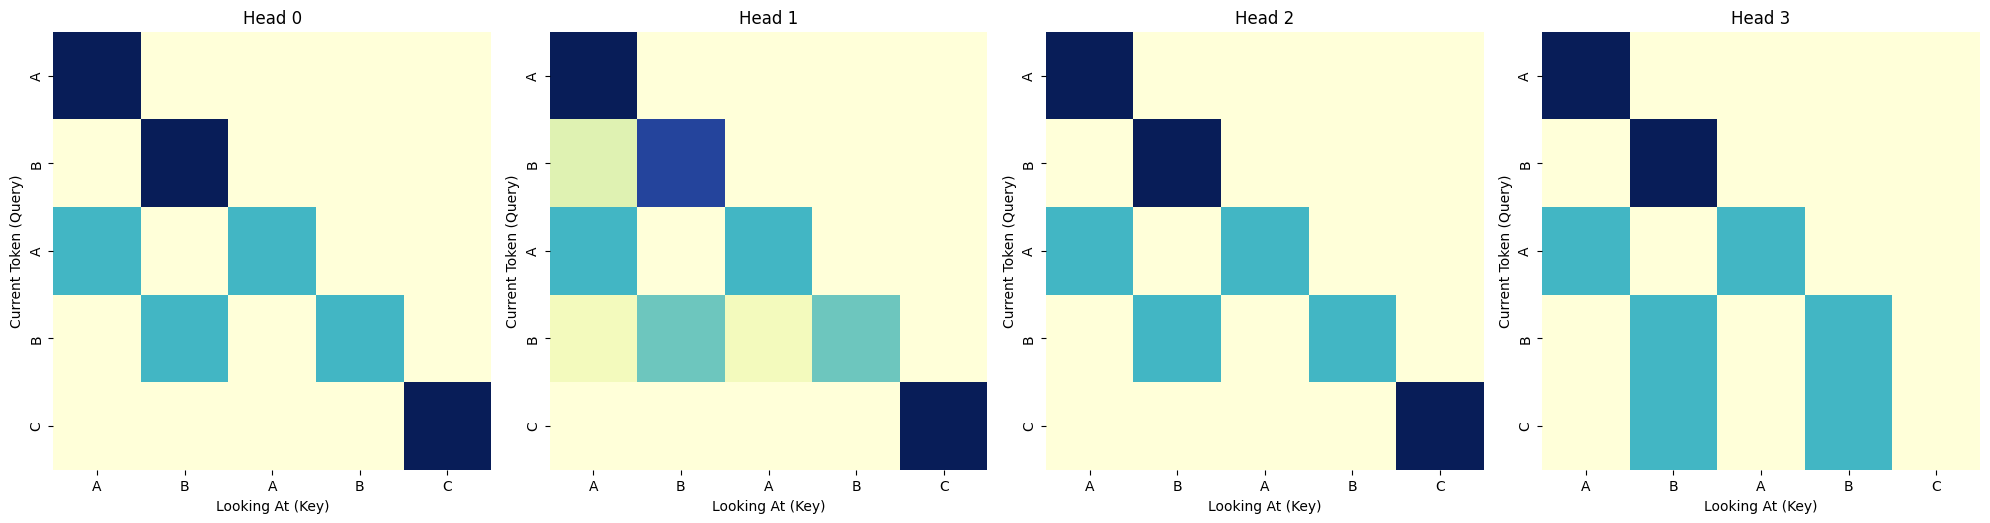

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define your vocabulary mapping clearly
# 0 -> A, 1 -> B, etc.
num_to_char = {i: chr(65 + i) for i in range(10)}


def plot_attention_simple(model, sequence):
    model.eval()

    # Translate the input numbers to letters for the plot labels
    # e.g., [0, 1, 2] becomes ['A', 'B', 'C']
    tokens = [num_to_char[t.item()] for t in sequence[0]]

    with torch.no_grad():
        # Pass through embedding then attention
        x = model.embedding(sequence)
        _, attn = model.attention(x, return_attn=True)

    # Let's look at all 4 heads side-by-side
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    for i in range(4):
        weights = attn[0, i].cpu().numpy()
        sns.heatmap(weights, xticklabels=tokens, yticklabels=tokens, cmap="YlGnBu", ax=axes[i], cbar=False, square=True)
        axes[i].set_title(f"Head {i}")
        axes[i].set_xlabel("Looking At (Key)")
        axes[i].set_ylabel("Current Token (Query)")

    plt.tight_layout()
    plt.show()


# Test with a sequence:
test_seq = torch.tensor([[0, 1, 0, 1, 2]])
plot_attention_simple(model, test_seq)

### The "Bag of Words" Problem

The reason these maps look like "blocks" rather than smooth lines is that the model is treating your sequence like a Bag of Words.

* In a Bag of Words: "A B C" is the same as "C B A".

* In your Attention Layer: Since Wq​ and Wk​ only multiply the embedding, the "score" for an A looking at a B will be identical whether they are next to each other or 100 miles apart.

### Let's add a simple positional encoding som model can understand "time"

In [12]:
class MiniGPT(nn.Module):
    def __init__(self, vocab_size, embed_size, heads, max_seq_len=20):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)

        # NEW: Positional Embedding layer
        self.pos_embedding = nn.Embedding(max_seq_len, embed_size)

        self.attention = CausalMultiHeadAttention(embed_size, heads)
        self.fc_out = nn.Linear(embed_size, vocab_size)

    def forward(self, x):
        batch_size, seq_len = x.shape

        # Create positions: [0, 1, 2, ..., seq_len-1]
        positions = torch.arange(0, seq_len).expand(batch_size, seq_len).to(x.device)

        # Sum the token and position embeddings
        x = self.embedding(x) + self.pos_embedding(positions)

        x = self.attention(x)
        logits = self.fc_out(x)
        return logits

In [13]:
# 1. hyperparams/configuration
vocab_size = 10  # Tokens 0 through 9
embed_size = 32  # "features"
heads = 4

model = MiniGPT(vocab_size, embed_size, heads)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

# 2. Training Loop
for epoch in range(300):
    # Create a simple repeating pattern: [0, 1, 2, 3, 0, 1, 2, 3...]
    # Batch size 4, Sequence length 8
    input_seq = torch.tensor([[0, 1, 2, 3, 4, 0, 1, 2]] * 4)

    # Target is the input shifted by one: [1, 2, 3, 4, 0, 1, 2, 3]
    target_seq = torch.tensor([[1, 2, 3, 4, 0, 1, 2, 3]] * 4)

    # Forward
    logits = model(input_seq)

    # CrossEntropy expects (Batch * Seq, Vocab_Size)
    loss = criterion(logits.view(-1, vocab_size), target_seq.view(-1))

    # Backward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f}")

# 3. Test the "Generation"
model.eval()
test_input = torch.tensor([[0, 1, 2]])  # Start with "A B C"
with torch.no_grad():
    prediction = model(test_input)
    next_token = torch.argmax(prediction[:, -1, :], dim=-1)
    print(f"\nInput: [0, 1, 2] | Predicted Next Token: {next_token.item()}")

Epoch 0 | Loss: 2.4987
Epoch 50 | Loss: 0.0000
Epoch 100 | Loss: 0.0000
Epoch 150 | Loss: 0.0000
Epoch 200 | Loss: 0.0000
Epoch 250 | Loss: 0.0000

Input: [0, 1, 2] | Predicted Next Token: 3


In [14]:
# 0, 1, 0, 1, {2}
model.eval()
test_input = torch.tensor([[0, 1, 0, 1, 2]])
with torch.no_grad():
    prediction = model(test_input)
    next_token = torch.argmax(prediction[:, -1, :], dim=-1)
    print(f"\nInput: [0, 1, 0, 1, 2] | Predicted Next Token: {next_token.item()}")


Input: [0, 1, 0, 1, 2] | Predicted Next Token: 3


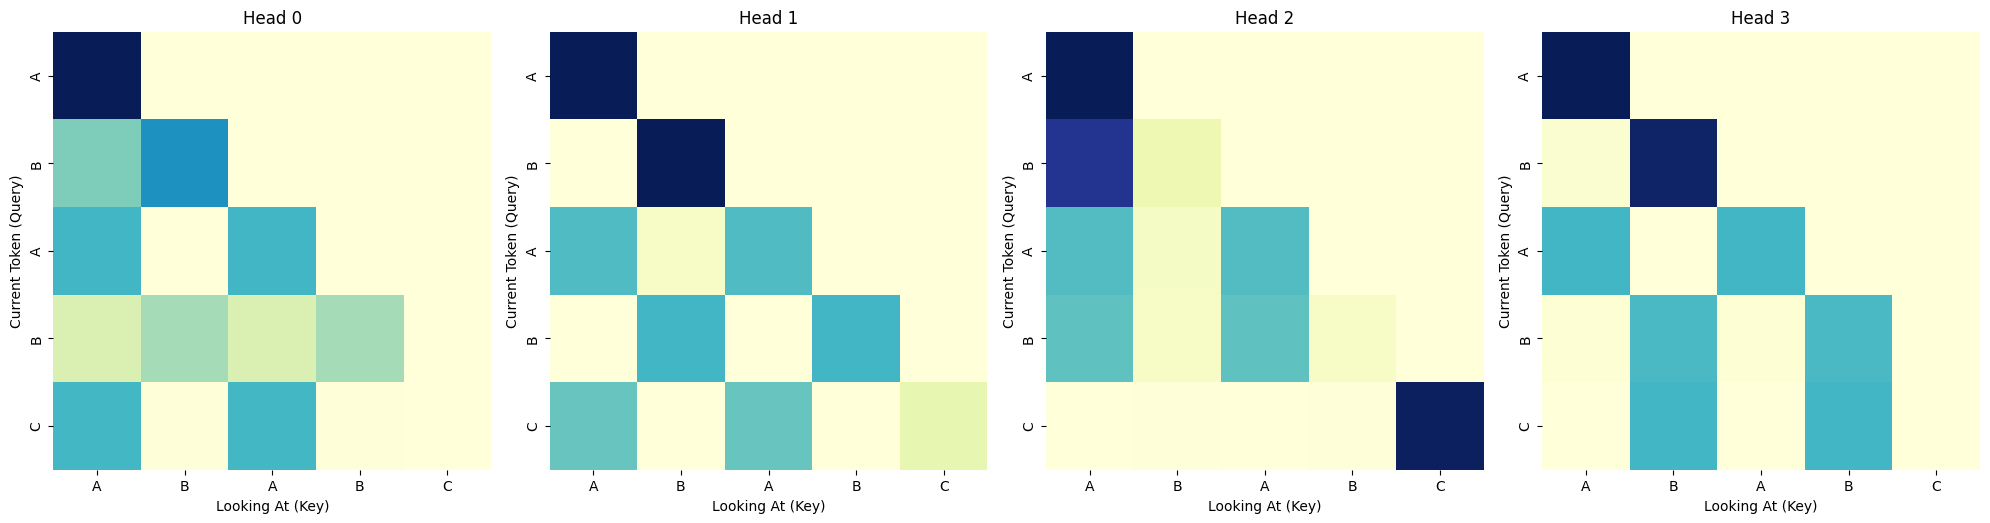

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define your vocabulary mapping clearly
# 0 -> A, 1 -> B, etc.
num_to_char = {i: chr(65 + i) for i in range(10)}


def plot_attention_simple(model, sequence):
    model.eval()

    # Translate the input numbers to letters for the plot labels
    # e.g., [0, 1, 2] becomes ['A', 'B', 'C']
    tokens = [num_to_char[t.item()] for t in sequence[0]]

    with torch.no_grad():
        # Pass through embedding then attention
        x = model.embedding(sequence)
        _, attn = model.attention(x, return_attn=True)

    # Let's look at all 4 heads side-by-side
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    for i in range(4):
        weights = attn[0, i].cpu().numpy()
        sns.heatmap(weights, xticklabels=tokens, yticklabels=tokens, cmap="YlGnBu", ax=axes[i], cbar=False, square=True)
        axes[i].set_title(f"Head {i}")
        axes[i].set_xlabel("Looking At (Key)")
        axes[i].set_ylabel("Current Token (Query)")

    plt.tight_layout()
    plt.show()


# Test with a sequence:
test_seq = torch.tensor([[0, 1, 0, 1, 2]])
plot_attention_simple(model, test_seq)

This looks significantly more structured! By adding **Positional Encoding**, you’ve given the model a "clock." Now, instead of just seeing a "B," it sees "B at time 1" versus "B at time 6."

**Positional Clarity:** This version uses positional encoding effectively. Notice how in Head 1, the second "B" (Query) is looking at the first "B" (Key). Without positional encoding, it couldn't tell the difference between the two.